TUGAS PRAKTIKUM 1

PEMROGRAMAN PARALEL

Nama  : Rifki Abdillah Al Afif 

NIM   : 2411512027

Kelas : A

1. Klasifikasi Flynn

a. Operasi arr + arr pada NumPy array

Kategori: SIMD (Single Instruction, Multiple Data)

Alasan:
Satu instruksi operasi diterapkan terhadap banyak elemen data pada array secara bersamaan. Oleh karena itu, operasi arr + arr termasuk dalam kategori SIMD.

b. Program Python biasa yang membaca file kemudian memproses baris demi baris

Kategori: SISD (Single Instruction, Single Data)

Alasan:
Program menjalankan satu aliran instruksi untuk memproses data secara berurutan. Tidak terdapat beberapa aliran instruksi yang bekerja secara paralel.

c. Cluster komputer yang menjalankan simulasi cuaca berbeda untuk wilayah berbeda secara independen

Kategori: MIMD (Multiple Instruction, Multiple Data)

Alasan:
Beberapa komputer atau node menjalankan instruksi yang berbeda terhadap data yang berbeda secara independen. Hal tersebut sesuai dengan karakteristik MIMD.

2. Analisis Hukum Amdahl

Hukum Amdahl digunakan untuk menghitung speedup suatu program ketika sebagian program dapat diproses secara paralel.

Rumus yang digunakan:

S(N) = 1 / ((1 - P) + (P / N))

Keterangan:
P = proporsi program yang dapat diparalelkan
N = jumlah prosesor
S(N) = speedup

In [1]:
def amdahl_speedup(P, N):
    return 1 / ((1 - P) + (P / N))


P = 0.85
jumlah_prosesor = [2, 4, 8, 16, 32, 64]

speedup = []

for N in jumlah_prosesor:
    S = amdahl_speedup(P, N)
    speedup.append(S)

    print(f"N = {N:2d} -> Speedup = {S:.4f}x")

N =  2 -> Speedup = 1.7391x
N =  4 -> Speedup = 2.7586x
N =  8 -> Speedup = 3.9024x
N = 16 -> Speedup = 4.9231x
N = 32 -> Speedup = 5.6637x
N = 64 -> Speedup = 6.1244x


Berdasarkan hasil perhitungan dengan P = 0.85, diperoleh speedup sebagai berikut:

Jumlah Prosesor    Speedup
2                  1.7391x
4                  2.7586x
8                  3.9024x
16                 4.9231x
32                 5.6637x
64                 6.1244x

Hasil tersebut menunjukkan bahwa speedup meningkat seiring dengan bertambahnya jumlah prosesor.

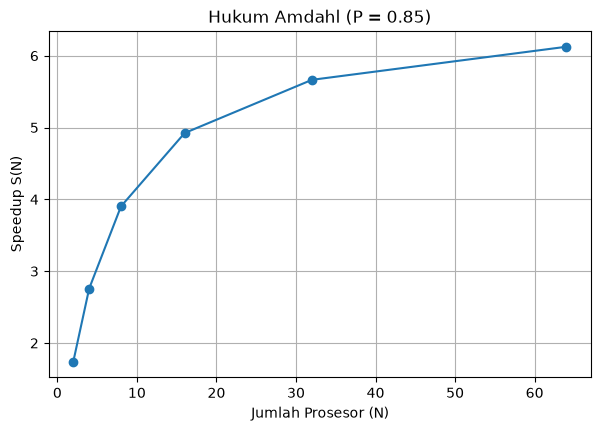

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4.5))

plt.plot(
    jumlah_prosesor,
    speedup,
    marker='o'
)

plt.title("Hukum Amdahl (P = 0.85)")
plt.xlabel("Jumlah Prosesor (N)")
plt.ylabel("Speedup S(N)")
plt.grid(True)

plt.show()

Diminishing returns terjadi ketika penambahan jumlah prosesor masih meningkatkan speedup, tetapi peningkatan yang diperoleh semakin kecil.

Berdasarkan hasil perhitungan, peningkatan speedup mulai semakin kecil ketika jumlah prosesor bertambah besar. Hal ini disebabkan oleh adanya bagian program yang tidak dapat diparalelkan.

Dengan P = 0.85, sebesar 85% program dapat diparalelkan, sedangkan 15% sisanya tetap bersifat serial. Bagian serial tersebut membatasi peningkatan speedup sehingga penambahan prosesor dalam jumlah besar memberikan peningkatan performa yang semakin kecil.

Diminishing returns semakin terlihat pada penggunaan prosesor yang lebih tinggi, terutama setelah 16 prosesor.

3. Benchmark CPU-bound

Benchmark dilakukan terhadap fungsi hitung_prima() untuk mengukur waktu eksekusi program.

Dua metode pengukuran yang digunakan adalah time.perf_counter() dan timeit.

Ukuran input yang digunakan adalah 10.000, 20.000, 40.000, 80.000, dan 160.000.

In [4]:
pip install pandas

   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/10.0 MB 11.6 MB/s eta 0:00:01
   ----- ---------------------------------- 1.3/10.0 MB 11.6 MB/s eta 0:00:01
   -------------- ------------------------- 3.7/10.0 MB 6.7 MB/s eta 0:00:01
   ------------------------- -------------- 6.3/10.0 MB 8.3 MB/s eta 0:00:01
   ------------------------------- -------- 7.9/10.0 MB 8.1 MB/s eta 0:00:01
   -------------------------------------- - 9.7/10.0 MB 8.3 MB/s eta 0:00:01
   ---------------------------------------- 10.0/10.0 MB 7.7 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [6]:
import time
import timeit
import pandas as pd
import matplotlib.pyplot as plt


def hitung_prima(n):
    primes = []

    for num in range(2, n):
        is_prime = True

        for i in range(2, int(num ** 0.5) + 1):
            if num % i == 0:
                is_prime = False
                break

        if is_prime:
            primes.append(num)

    return primes


ukuran_input = [10000, 20000, 40000, 80000, 160000]

hasil = []

for N in ukuran_input:

    start = time.perf_counter()

    bilangan_prima = hitung_prima(N)

    waktu_perf = time.perf_counter() - start

    waktu_timeit = timeit.repeat(
        stmt="hitung_prima(N)",
        globals={
            "hitung_prima": hitung_prima,
            "N": N
        },
        number=1,
        repeat=5
    )

    waktu_timeit_terbaik = min(waktu_timeit)
    waktu_timeit_rata = sum(waktu_timeit) / len(waktu_timeit)

    hasil.append([
        N,
        len(bilangan_prima),
        waktu_perf,
        waktu_timeit_terbaik,
        waktu_timeit_rata
    ])


tabel = pd.DataFrame(
    hasil,
    columns=[
        "Ukuran Input",
        "Jumlah Prima",
        "perf_counter (detik)",
        "timeit Terbaik (detik)",
        "timeit Rata-rata (detik)"
    ]
)

tabel

,Ukuran Input,Jumlah Prima,perf_counter (detik),timeit Terbaik (detik),timeit Rata-rata (detik)
0,10000,1229,0.013295,0.020194,0.021370
1,20000,2262,0.049074,0.049146,0.051155
2,40000,4203,0.124298,0.119336,0.121227
3,80000,7837,0.271214,0.268018,0.293691
4,160000,14683,0.762350,0.743607,0.763637


Berdasarkan hasil benchmark, waktu eksekusi cenderung meningkat ketika ukuran input semakin besar.

Hal tersebut terjadi karena fungsi hitung_prima() harus memeriksa lebih banyak bilangan untuk menentukan bilangan prima.

time.perf_counter() digunakan untuk mengukur waktu eksekusi secara langsung. Sementara itu, timeit melakukan pengukuran secara berulang sehingga dapat digunakan untuk memperoleh waktu terbaik dan waktu rata-rata.

Perbedaan waktu pengukuran antara kedua metode dapat terjadi karena kondisi komputer dan proses lain yang sedang berjalan selama pengujian.

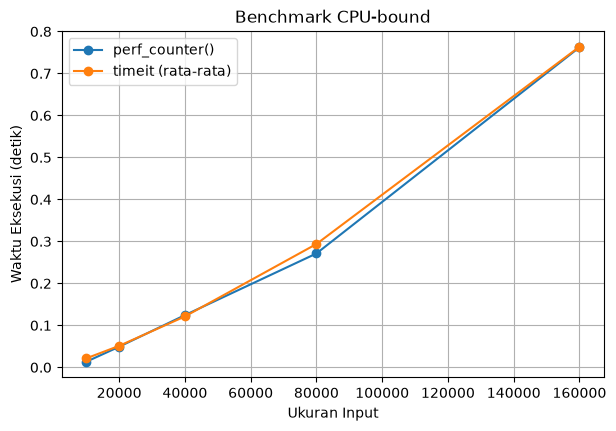

In [7]:
plt.figure(figsize=(7, 4.5))

plt.plot(
    tabel["Ukuran Input"],
    tabel["perf_counter (detik)"],
    marker='o',
    label="perf_counter()"
)

plt.plot(
    tabel["Ukuran Input"],
    tabel["timeit Rata-rata (detik)"],
    marker='o',
    label="timeit (rata-rata)"
)

plt.title("Benchmark CPU-bound")
plt.xlabel("Ukuran Input")
plt.ylabel("Waktu Eksekusi (detik)")
plt.legend()
plt.grid(True)

plt.show()

4. Refleksi

Hukum Amdahl lebih relevan ketika ukuran masalah tetap dan kita ingin mengetahui peningkatan performa akibat penambahan prosesor. Contohnya adalah pengolahan sebuah gambar dengan ukuran tetap menggunakan beberapa prosesor. Bagian program yang tidak dapat diparalelkan akan membatasi speedup yang dapat diperoleh.

Hukum Gustafson lebih relevan ketika ukuran masalah dapat diperbesar seiring bertambahnya jumlah prosesor. Contohnya adalah simulasi cuaca yang dapat mencakup wilayah atau jumlah data yang lebih besar ketika menggunakan lebih banyak komputer.

Dengan demikian, Hukum Amdahl berfokus pada percepatan masalah dengan ukuran tetap, sedangkan Hukum Gustafson berfokus pada kemampuan menyelesaikan masalah yang lebih besar dengan sumber daya yang lebih banyak.